# Frontdoor Criterion

Uber와 Lyft의 공유 탑승이 팁에 미치는 인과효과를 추정하고자 합니다.

- 업계에서 운전자들은 “공유 탑승을 허용하는 행동 자체가 팁 감소를 야기한다”고 믿는 경향이 있습니다.
- 그러나 공유 탑승 허용(X)은 무작위로 할당할 수 없고, 절약 성향 등 관찰할 수 없는 요인과 연관되어 내생성(endogeneity) 문제가 존재합니다.
    
    예컨대 절약적인 사람일수록 공유 탑승을 허용할 가능성이 높고, 팁을 덜 줄 가능성이 높습니다(Selection Bias).

이러한 내생성을 완화하기 위해 Front-Door Criterion (FDC) 을 적용합니다.

이를 통해 공유 탑승 허용(X) → 실제 공유 탑승 발생(M) → 팁(Y) 간의 인과경로를 분리하여 식별합니다.
- **X**: 공유 탑승 허용 여부
- **M:** 실제 공유 발생
- **Y**: 팁(여부/금액/요금대비 비율)

핵심 아이디어는 앱의 매칭 알고리즘이 만들어내는 M의 외생적 변동을 활용해, “공유 탑승을 승인하는 사람의 유형(절약 성향 등)”으로 인한 선택편향을 제거하고, 합승 자체의 효과를 분리하는 것입니다.

- **Dataset**: [NYC TLC — 2023 High Volume For-Hire Vehicle Trip Records](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data) (Uber·Lyft 등 HVFHS 운행 데이터, 약 2.3억건)
- **Reference**: *The Paper of How: Estimating Treatment Effects Using the Front-Door Criterion*

In [1]:
%%capture
%pip install duckdb==1.0.0 polars==1.6.0 pandas==2.2.2 pyarrow==16.1.0 statsmodels==0.14.2 numpy==2.0.1 dowhy

In [2]:
import duckdb, pandas as pd, numpy as np
import statsmodels.api as sm
import warnings
from dowhy import CausalModel

warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*", module="dowhy")

/Users/hc.cho/Projects/awesome-causal-inference-python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Identification Strategy

현실 데이터에서 FDC의 가정들이 자동으로 성립하지 않기 때문에, 조건부 외생성(conditional exogeneity) 을 확보해야 합니다.
다음 세 가지 내생성 원인을 다룹니다.

- 요금 내생성 (Fare endogeneity)
  - **X–Y backdoor**: 승객은 승차 전 앱에서 요금(fare)을 보고 단독(solo) 또는 공유(sharing)을 직접 선택합니다.  
    
    이때 낮은 요금일수록 공유 승인(X=1) 확률은 높고, 팁(Y)은 낮아지는 경향있을 수 있습니다. 
  - **M–Y backdoor**: 피크·혼잡 요금은 M(실제 공유 성사)과 Y에도 동시에 작용할 수 있습니다. 
  - **대응**: 모든 추정 단계에 통제변수로 포함하여 요금 기반의 혼란(confounding)을 제거했습니다.

- 시간·공간 내생성 (Time–place endogeneity)
  - **X–M backdoor**: 특정 시간대(출퇴근, 심야, 이벤트)나 지역에서는 공유 승인(X) 확률이 높을 수 있습니다.
  - **M–Y backdoor**: 공유 성사 확률(M)은 시간대·지역·수요 상황에 따라 달라지며, 이러한 요인들은 팁(Y)에도 동시에 영향을 줄 수 있습니다.
  - **대응**:
    출발–도착지(OD)와 2시간 단위의 시간–공간 조합별로 셀 평균을 제거(**demeaning**)하여  

    동일한 시공간 내 변동만을 이용해 추정했습니다.  

    이는 **고정효과(Fixed Effects, FE)** 를 적용한 것과 동일하며,  
    
    시간·공간 요인으로 인한 X–M 및 M–Y backdoor 경로를 동시에 차단합니다.
  
- 선택편향/유형효과 (Selection into X)
  - 절약 성향(U) 이 강한 사람일수록 공유 탑승을 승인할 확률(X=1)이 높고, 팁(Y)은 낮습니다.
    
    → 단순 OLS는 음(-)효과 과대
    
    → FDC로 X→M, M→Y를 분리 추정하고, 외생적 M 변동만으로 효과 식별

또한, one-sided noncompliance(실제 공유 탑승 M=1은 승인 X=1에서만 발생)가 대체로 성립하면, FDC 추정치는 ATT 해석에 가까워집니다.

### Model

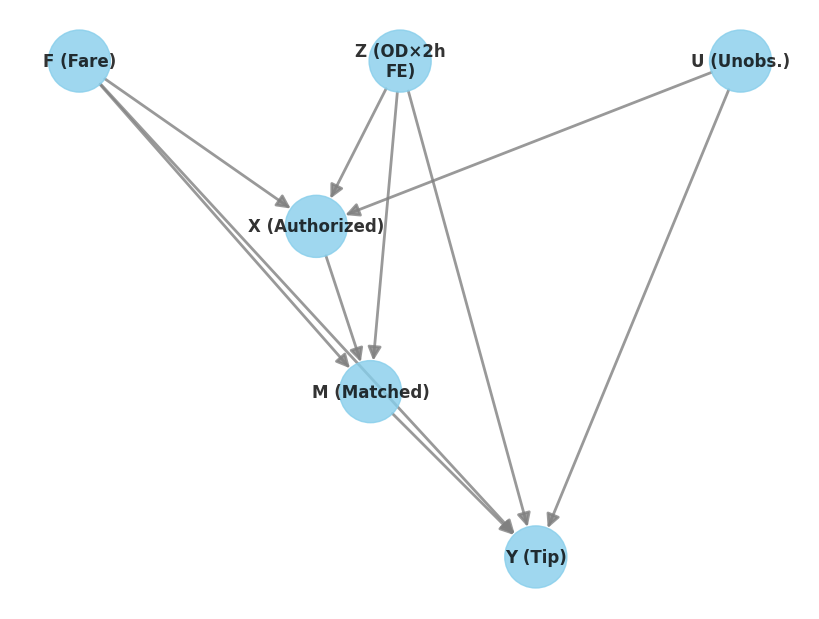

In [3]:
gml_frontdoor = """
graph [
  directed 1
  node [ id "X" label "X (Authorized)" ]
  node [ id "M" label "M (Matched)" ]
  node [ id "Y" label "Y (Tip)" ]
  node [ id "F" label "F (Fare)" ]
  node [ id "Z" label "Z (OD×2h FE)" ]
  node [ id "U" label "U (Unobs.)" observed 0 ]

  edge [ source "X" target "M" ]
  edge [ source "M" target "Y" ]

  edge [ source "F" target "X" ]
  edge [ source "F" target "M" ]
  edge [ source "F" target "Y" ]

  edge [ source "Z" target "X" ]
  edge [ source "Z" target "M" ]
  edge [ source "Z" target "Y" ]

  edge [ source "U" target "X" ]
  edge [ source "U" target "Y" ]
]
"""

df_dummy = pd.DataFrame({
    "X": [0, 1],
    "M": [0, 1],
    "Y": [0, 1],
    "F": [0.0, 0.0],
    "Z": [0.0, 0.0],
})

cm = CausalModel(
    data=df_dummy,
    treatment="X",
    outcome="Y",
    graph=gml_frontdoor
)

cm.view_model(layout="dot")


## Data Setup

큰 파일(2.3억 행)이므로 DuckDB의 lazy scan을 사용합니다.

In [4]:
parquet_url = "https://huggingface.co/datasets/Funbucket/nyc-hvfhs-2023/resolve/main/nyc_hvfhs_2023.parquet"
# parquet_url = "../data/nyc_hvfhs_2023.parquet"
con = duckdb.connect()

con.execute("INSTALL httpfs; LOAD httpfs;")

In [5]:
schema_df = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{parquet_url}')
""").df()

sample_df = con.execute(f"""
SELECT *
FROM read_parquet('{parquet_url}')
LIMIT 5
""").df()

display(schema_df)
display(sample_df.head())

,column_name,column_type,null,key,default,extra
0,hvfhs_license_num,VARCHAR,YES,None,None,None
1,dispatching_base_num,VARCHAR,YES,None,None,None
2,request_datetime,VARCHAR,YES,None,None,None
3,pickup_datetime,TIMESTAMP WITH TIME ZONE,YES,None,None,None
4,dropoff_datetime,VARCHAR,YES,None,None,None
5,pulocationid,VARCHAR,YES,None,None,None
6,dolocationid,VARCHAR,YES,None,None,None
7,trip_miles,VARCHAR,YES,None,None,None
8,trip_time,VARCHAR,YES,None,None,None
9,base_passenger_fare,VARCHAR,YES,None,None,None


,hvfhs_license_num,dispatching_base_num,request_datetime,pickup_datetime,dropoff_datetime,pulocationid,dolocationid,trip_miles,trip_time,base_passenger_fare,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,originating_base_num,on_scene_datetime
0,HV0005,B03406,2022-12-31T23:57:01.000,2023-01-01 09:00:00+09:00,2023-01-01T00:36:41.000,233,48,1.946,2201,15.11,...,0.0,0.0,21.8,N,N,N,N,False,None,None
1,HV0003,B03404,2022-12-31T23:57:11.000,2023-01-01 09:00:00+09:00,2023-01-01T00:06:59.000,247,167,1.66,419,10.54,...,0.0,0.0,6.48,N,N,None,N,False,B03404,2022-12-31T23:59:51.000
2,HV0005,B03406,2022-12-31T23:54:24.000,2023-01-01 09:00:00+09:00,2023-01-01T00:05:47.000,228,227,1.327,347,7.76,...,0.0,1.0,5.47,N,N,N,N,False,None,None
3,HV0005,B03406,2022-12-31T23:57:47.000,2023-01-01 09:00:00+09:00,2023-01-01T00:54:20.000,152,149,23.633,3260,58.04,...,0.0,14.16,64.29,N,N,N,N,True,None,None
4,HV0003,B03404,2022-12-31T23:55:54.000,2023-01-01 09:00:01+09:00,2023-01-01T00:09:23.000,157,160,2.2,562,10.02,...,0.0,0.0,8.27,N,N,None,N,False,B03404,2022-12-31T23:59:33.000


read_parquet를 여러 단계에서 중복 호출하지 않도록 원본 스캔을 뷰로 고정합니다.

In [6]:
# lazy anchor
con.execute(f"""
CREATE OR REPLACE VIEW hvfhs AS
SELECT
  hvfhs_license_num,
  dispatching_base_num,
  request_datetime,             
  pickup_datetime,
  dropoff_datetime,             
  pulocationid, dolocationid,   
  trip_miles, trip_time,        
  base_passenger_fare, tolls, bcf, sales_tax,
  congestion_surcharge, airport_fee, tips, driver_pay,
  shared_request_flag, shared_match_flag,                
  access_a_ride_flag, wav_request_flag,                  
  wav_match_flag,                                       
  originating_base_num, on_scene_datetime
FROM read_parquet('{parquet_url}');
""")

### 타입 정규화

In [7]:
con.execute("""
CREATE OR REPLACE VIEW hvfhs_typed AS
WITH t AS (
  SELECT
    h.*,

    TRY_CAST(base_passenger_fare AS DECIMAL(18,2))    AS base_passenger_fare_c,
    TRY_CAST(tolls               AS DECIMAL(18,2))    AS tolls_c,
    TRY_CAST(bcf                 AS DECIMAL(18,2))    AS bcf_c,
    TRY_CAST(sales_tax           AS DECIMAL(18,2))    AS sales_tax_c,
    TRY_CAST(congestion_surcharge AS DECIMAL(18,2))   AS congestion_surcharge_c,
    TRY_CAST(airport_fee         AS DECIMAL(18,2))    AS airport_fee_c,
    TRY_CAST(tips                AS DECIMAL(18,2))    AS tips_c,
    TRY_CAST(driver_pay          AS DECIMAL(18,2))    AS driver_pay_c,

    TRY_CAST(trip_miles          AS DOUBLE)           AS trip_miles_d,
    TRY_CAST(trip_time           AS DOUBLE)           AS trip_time_d,

    TRY_CAST(pulocationid AS INTEGER) AS pulocationid_i,
    TRY_CAST(dolocationid AS INTEGER) AS dolocationid_i,

    CASE WHEN LOWER(TRIM(COALESCE(shared_request_flag,''))) IN ('y','yes','true','1') THEN 1 ELSE 0 END AS X_authorized,
    CASE WHEN LOWER(TRIM(COALESCE(shared_match_flag,'')))   IN ('y','yes','true','1') THEN 1 ELSE 0 END AS M_shared,

    TRY_STRPTIME(request_datetime,  '%Y-%m-%d %H:%M:%S') AS request_ts,
    TRY_STRPTIME(dropoff_datetime,  '%Y-%m-%d %H:%M:%S') AS dropoff_ts,
    TRY_STRPTIME(on_scene_datetime, '%Y-%m-%d %H:%M:%S') AS on_scene_ts
  FROM hvfhs h
)
SELECT * FROM t;

""")


### 파생변수

- Full fare = base + tolls + sales_tax + congestion_surcharge + airport_fee + bcf
- 결과변수:
  - **팁 유무**: Y_tip_dummy
  - **팁 금액**: Y_tip_amount 
  - **팁/요금 비율**: Y_tip_share 
- **2시간 슬롯**: 0..11 (하루 12개 셀)
- **품질 필터**: 음수/결측/이상치 제거

In [8]:
con.execute("""
CREATE OR REPLACE VIEW hvfhs_prep AS
WITH base AS (
  SELECT
    *,
    
    COALESCE(base_passenger_fare_c,  0)
  + COALESCE(tolls_c,                0)
  + COALESCE(sales_tax_c,            0)
  + COALESCE(congestion_surcharge_c, 0)
  + COALESCE(airport_fee_c,          0)
  + COALESCE(bcf_c,                  0) AS full_fare_c,

    CAST(
      FLOOR(EXTRACT(HOUR FROM (pickup_datetime AT TIME ZONE 'America/New_York')) / 2.0)
      AS INTEGER
    ) AS time_slot_2h
  FROM hvfhs_typed
),
prep AS (
  SELECT
    *,
    
    CASE WHEN COALESCE(tips_c, 0) > 0 THEN 1 ELSE 0 END AS Y_tip_dummy,
    COALESCE(tips_c, 0)                                 AS Y_tip_amount_c,
    CASE 
      WHEN full_fare_c > 0 THEN COALESCE(tips_c, 0) / full_fare_c 
      ELSE NULL 
    END AS Y_tip_share_c
  FROM base
  WHERE
    COALESCE(trip_time_d,  0.0) >= 0.0
    AND COALESCE(trip_miles_d, 0.0) >= 0.0
    AND pickup_datetime IS NOT NULL
    AND pulocationid IS NOT NULL
    AND dolocationid IS NOT NULL
)
SELECT
  
  *,
  CAST(full_fare_c      AS DOUBLE) AS full_fare,
  CAST(Y_tip_amount_c   AS DOUBLE) AS Y_tip_amount,
  CAST(Y_tip_share_c    AS DOUBLE) AS Y_tip_share
FROM prep
WHERE
  full_fare_c >= 3.00
  AND (Y_tip_share_c IS NULL OR Y_tip_share_c BETWEEN 0 AND 5.00);

""")

con.execute("SELECT COUNT(*) AS n FROM hvfhs_prep").df().head()


,n
0,232411474


### One-Sided Noncompliance 점검

- M=1이면 거의 항상 X=1인지 여부 확인(낮은 위반율이면 양호)

- 위반 행을 제외한 재추정으로 민감도 체크 가능

In [9]:
con.execute("""
SELECT
  SUM(CASE WHEN M_shared=1 AND X_authorized=0 THEN 1 ELSE 0 END) AS violations,
  SUM(CASE WHEN M_shared=1 THEN 1 ELSE 0 END)                     AS all_shared,
  1.0 * SUM(CASE WHEN M_shared=1 AND X_authorized=0 THEN 1 ELSE 0 END)
      / NULLIF(SUM(CASE WHEN M_shared=1 THEN 1 ELSE 0 END),0)     AS violation_rate
FROM hvfhs_prep
""").fetchdf()


,violations,all_shared,violation_rate
0,13606.0,2062149.0,0.006598


### 시간×공간 고정효과: demeaning

- 수많은 더미 대신 OD×2h 셀 내 평균을 제거하는 방법을 사용합니다.
- **셀 정의**: `pulocationid`, `dolocationid`, `time_slot_2h`

In [10]:
SAMPLE_RATE = 0.1

con.execute(f"""
CREATE OR REPLACE TEMP VIEW sample AS
SELECT *
FROM hvfhs_prep
USING SAMPLE {int(SAMPLE_RATE*100)} PERCENT (bernoulli)
""")

# 셀 평균(OD×2h)
con.execute("""
CREATE OR REPLACE TEMP VIEW cell_means AS
SELECT
  pulocationid_i AS pu,
  dolocationid_i AS do,
  time_slot_2h   AS ts,
  AVG(X_authorized) AS X_bar,
  AVG(M_shared)     AS M_bar,
  AVG(full_fare)    AS F_bar,
  AVG(Y_tip_dummy)  AS Yd_bar,
  AVG(Y_tip_amount) AS Ya_bar,
  AVG(Y_tip_share)  AS Ys_bar,
  COUNT(*)          AS n_cell
FROM sample
GROUP BY 1,2,3
""")

# demeaning
con.execute("""
CREATE OR REPLACE TEMP VIEW demeaned AS
SELECT
  s.pulocationid_i AS pu,
  s.dolocationid_i AS do,
  s.time_slot_2h   AS ts,

  (s.X_authorized - m.X_bar) AS X_tilde,
  (s.M_shared     - m.M_bar) AS M_tilde,
  (s.full_fare    - m.F_bar) AS F_tilde,

  (s.Y_tip_dummy  - m.Yd_bar) AS Yd_tilde,
  (s.Y_tip_amount - m.Ya_bar) AS Ya_tilde,
  (s.Y_tip_share  - m.Ys_bar) AS Ys_tilde
FROM sample s
JOIN cell_means m
  ON s.pulocationid_i = m.pu
 AND s.dolocationid_i = m.do
 AND s.time_slot_2h   = m.ts
WHERE s.Y_tip_share IS NOT NULL
""")

df = con.execute("SELECT * FROM demeaned").fetchdf()
df.info(show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23151441 entries, 0 to 23151440
Data columns (total 9 columns):
 #   Column    Non-Null Count     Dtype  
---  ------    --------------     -----  
 0   pu        23151441 non-null  int32  
 1   do        23151441 non-null  int32  
 2   ts        23151441 non-null  int32  
 3   X_tilde   23151441 non-null  float64
 4   M_tilde   23151441 non-null  float64
 5   F_tilde   23151441 non-null  float64
 6   Yd_tilde  23151441 non-null  float64
 7   Ya_tilde  23151441 non-null  float64
 8   Ys_tilde  23151441 non-null  float64
dtypes: float64(6), int32(3)
memory usage: 1.3 GB


## Estimate — Parametric

### FDC 가정

1. X의 Y에 대한 효과는 전부 M을 경유한다.  
2. X–M backdoor 없음: (F, FE) 통제해 충족
3. M–Y backdoor 없음: (X, F, FE) 통제해 충족
    
    → $Y(m) \perp M \mid X,\ \text{Fare},\ \text{FE}$

### First stage

$$
M = \kappa + \gamma X + \tau F + FE + \omega
$$
- FDC 가정 (2)을 충족하기 위해 X–M 사이의 backdoor는 Fare, 시간·공간 FE로 차단합니다.  
- demeaning으로 FE 흡수 → 여기서는 $\tilde M$ ~ $\tilde X$ + $\tilde F$

In [11]:
X1 = sm.add_constant(df[['X_tilde','F_tilde']])
y1 = df['M_tilde']

model1 = sm.OLS(y1, X1).fit(cov_type='HC1')
gamma_hat = model1.params['X_tilde']
se_gamma  = model1.bse['X_tilde']
model1.summary().tables[1]


,coef,std err,z,P>|z|,[0.025,0.975]
const,-2.307e-05,1.62e-05,-1.424,0.154,-5.48e-05,8.68e-06
X_tilde,0.3267,0.001,569.008,0.000,0.326,0.328
F_tilde,-0.0002,1.15e-06,-143.447,0.000,-0.000,-0.000


### Second stage

$$
Y = \lambda + \delta M + \phi X + \pi F + FE + \nu
$$

- FDC 가정 (3)을 충족하기 위해 M–Y 사이의 backdoor는 Fare, 시간·공간 FE로 차단합니다. 
- demeaning으로 FE 흡수 → $\tilde Y$ ~ $\tilde M$ + $\tilde X$ + $\tilde F$

In [12]:
def second_stage(outcome_col):
    cols = ['M_tilde','X_tilde','F_tilde', outcome_col]
    d2 = df[cols].dropna()
    X2 = sm.add_constant(d2[['M_tilde','X_tilde','F_tilde']])
    y2 = d2[outcome_col]
    fit = sm.OLS(y2, X2).fit(cov_type='HC1')
    delta = fit.params['M_tilde']
    se    = fit.bse['M_tilde']
    return fit, delta, se

fit_dummy,  delta_d, se_d = second_stage('Yd_tilde')  # 팁 유무
fit_amount, delta_a, se_a = second_stage('Ya_tilde')  # 팁 금액
fit_share,  delta_s, se_s = second_stage('Ys_tilde')  # 팁 비율

fit_dummy.summary().tables[1]


,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0002,8.06e-05,2.278,0.023,2.57e-05,0.000
M_tilde,0.0101,0.001,12.071,0.000,0.008,0.012
X_tilde,-0.0713,0.000,-154.782,0.000,-0.072,-0.070
F_tilde,0.0008,8.12e-06,103.594,0.000,0.001,0.001


### Front Door Effect

- 총 효과는 1단계와 2단계 추정치의 곱으로 계산합니다.
  $Effect = \gamma \times \delta$
- 이론적으로는 ATE 형태지만, one-sided noncompliance 상황에서는 ATT, 즉 공유를 승인한 사람들(X=1) 내에서의 평균 효과로 해석됩니다. 
- 표준오차는 델타법으로 근사합니다.(보수적으로 Cov=0 가정)

    $$
    \operatorname{Var}(\gamma \delta) \approx 
    \delta^2 \operatorname{Var}(\gamma) +
    \gamma^2 \operatorname{Var}(\delta) +
    2\gamma\delta\,\operatorname{Cov}(\gamma, \delta)
    $$

In [13]:
def product_and_se(gamma, se_g, delta, se_d, cov_gd=0.0):
    var_prod = (delta**2)*(se_g**2) + (gamma**2)*(se_d**2) + 2*gamma*delta*cov_gd
    return gamma*delta, np.sqrt(var_prod)

def ci95(est, se):
    return est - 1.96*se, est + 1.96*se

ate_dummy,  se_ate_dummy  = product_and_se(gamma_hat, se_gamma, delta_d, se_d, cov_gd=0.0)
ate_amount, se_ate_amount = product_and_se(gamma_hat, se_gamma, delta_a, se_a, cov_gd=0.0)
ate_share,  se_ate_share  = product_and_se(gamma_hat, se_gamma, delta_s, se_s, cov_gd=0.0)

ci_dummy   = ci95(ate_dummy,  se_ate_dummy)
ci_amount  = ci95(ate_amount, se_ate_amount)
ci_share   = ci95(ate_share,  se_ate_share)

pd.DataFrame({
  'Outcome': ['Tip Dummy (Pr[tips>0])','Tip Amount ($)','Tip Share (tips/full_fare)'],
  'gamma_hat (X→M)': [gamma_hat]*3,
  'delta_hat (M→Y|X,F,FE)': [delta_d, delta_a, delta_s],
  'Front-Door ATE = γ×δ': [ate_dummy, ate_amount, ate_share],
  'SE (Delta method)': [se_ate_dummy, se_ate_amount, se_ate_share],
  '95% CI (lower, upper)': [ci_dummy, ci_amount, ci_share]
})


,Outcome,gamma_hat (X→M),"delta_hat (M→Y|X,F,FE)",Front-Door ATE = γ×δ,SE (Delta method),"95% CI (lower, upper)"
0,Tip Dummy (Pr[tips>0]),0.326655,0.010106,0.003301,0.000274,"(0.0027651286589001076, 0.003837404978435226)"
1,Tip Amount ($),0.326655,0.095022,0.031039,0.001537,"(0.028027341751846565, 0.03405158740277962)"
2,Tip Share (tips/full_fare),0.326655,0.003846,0.001256,0.000052,"(0.001154028793499864, 0.0013586671722652876)"


## Naive OLS와 비교 (선택편향의 크기 보기)

- Naive: $\tilde Y \sim \tilde X + \tilde F$ (M 없이) → 선택편향 포함
- Naive의 음(-) 추정과 달리, FDC 추정치는 작지만 양(+)의 효과로 유의하게 추정됨

    →  “공유 승인자들이 팁이 낮다”는 관찰된 관계의 대부분은 **선택편향**에서 비롯되며, **공유 자체의 인과효과는 거의 미미합니다.**

In [14]:
def naive(outcome_col):
    cols = ['X_tilde','F_tilde', outcome_col]
    dn = df[cols].dropna()
    Xn = sm.add_constant(dn[['X_tilde','F_tilde']])
    yn = dn[outcome_col]
    fit = sm.OLS(yn, Xn).fit(cov_type='HC1')
    b   = fit.params['X_tilde']
    se  = fit.bse['X_tilde']
    return fit, b, se

n_fit_d, nb_d, nse_d = naive('Yd_tilde')
n_fit_a, nb_a, nse_a = naive('Ya_tilde')
n_fit_s, nb_s, nse_s = naive('Ys_tilde')

pd.DataFrame({
  'Outcome': ['Tip Dummy','Tip Amount','Tip Share'],
  'Naive beta (X→Y)': [nb_d, nb_a, nb_s],
  'Naive SE': [nse_d, nse_a, nse_s],
  'FDC ATE (γ×δ)': [ate_dummy, ate_amount, ate_share],
  'FDC SE (Delta)': [se_ate_dummy, se_ate_amount, se_ate_share]
})


,Outcome,Naive beta (X→Y),Naive SE,FDC ATE (γ×δ),FDC SE (Delta)
0,Tip Dummy,-0.067952,0.000397,0.003301,0.000274
1,Tip Amount,-0.201049,0.002805,0.031039,0.001537
2,Tip Share,-0.013570,0.000077,0.001256,0.000052


## Estimate — Nonparametric

demeaning 된 데이터(=시공간 고정효과 제거)를 사용하여  
비모수적 Front-Door 추정을 수행합니다.

- **1단계:**  
  $$
  \hat{\gamma} = \mathbb{E}_{\tilde{F}}\big[\,\hat{m}(1-\bar{X}, \tilde{F}) - \hat{m}(0-\bar{X}, \tilde{F})\,\big]
  $$
  → 공유 승인(X)이 실제 매칭(M)에 미치는 평균적 효과

- **2단계:**  
  $$
  \hat{\delta} = \mathbb{E}_{\tilde{X},\tilde{F}}\big[\,\hat{y}(1-\bar{M}, \tilde{X}, \tilde{F}) - \hat{y}(0-\bar{M}, \tilde{X}, \tilde{F})\,\big]
  $$
  → 실제 공유(M)가 팁(Y)에 미치는 조건부 효과

- **최종 추정치:**  
  $$
  \widehat{\mathrm{FD}} = \hat{\gamma} \times \hat{\delta}
  $$

In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold

SAMPLE_RATE = 0.1
RANDOM_SEED = 123

In [16]:
# 데이터 결합 (demeaned + 셀 평균)
ml_df = con.execute(f"""
SELECT *
FROM (
  SELECT d.pu, d.do, d.ts,
         d.X_tilde, d.M_tilde, d.F_tilde,
         d.Yd_tilde, d.Ya_tilde, d.Ys_tilde,
         m.X_bar, m.M_bar
  FROM demeaned d
  JOIN cell_means m
    ON d.pu = m.pu
   AND d.do = m.do
   AND d.ts = m.ts
) t
USING SAMPLE {int(SAMPLE_RATE*100)} PERCENT (bernoulli)
""").df()

In [17]:
X_tilde = ml_df[['X_tilde','F_tilde']].to_numpy()
M_tilde = ml_df[['M_tilde','X_tilde','F_tilde']].to_numpy()
Xbar = ml_df['X_bar'].to_numpy()
Mbar = ml_df['M_bar'].to_numpy()

# 1단계: m(x, f)
X1_cf  = np.column_stack([1.0 - Xbar, ml_df['F_tilde'].to_numpy()])  # X=1 → (1−X̄, 𝐹̃)
X0_cf  = np.column_stack([0.0 - Xbar, ml_df['F_tilde'].to_numpy()])  # X=0 → (0−X̄, 𝐹̃)

# 2단계: y(m, x, f)
M1_cf  = np.column_stack([1.0 - Mbar, M_tilde[:,1], M_tilde[:,2]]) # M=1 → (1−M̄, 𝑋̃, 𝐹̃)
M0_cf  = np.column_stack([0.0 - Mbar, M_tilde[:,1], M_tilde[:,2]]) # M=0 → (0−M̄, 𝑋̃, 𝐹̃)

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def oof_diff_mean(X_train_like, y_tilde, A_cf_hi, A_cf_lo):
    diffs = []
    for tr, te in kf.split(X_train_like):
        g = GradientBoostingRegressor(random_state=RANDOM_SEED)
        g.fit(X_train_like[tr], y_tilde[tr])
        hi = g.predict(A_cf_hi[te])
        lo = g.predict(A_cf_lo[te])
        diffs.append(hi - lo)
    return float(np.mean(np.concatenate(diffs)))


In [19]:
# γ̂, δ̂ 추정 및 Front-Door 효과 계산

# γ̂: X → M | F
gamma_hat_np = oof_diff_mean(
    X_tilde,
    ml_df['M_tilde'].to_numpy(),
    X1_cf,
    X0_cf
)

# δ̂: M → Y | (X,F)
delta_d_np = oof_diff_mean(
    M_tilde,
    ml_df['Yd_tilde'].to_numpy(),
    M1_cf,
    M0_cf
)
delta_a_np = oof_diff_mean(
    M_tilde,
    ml_df['Ya_tilde'].to_numpy(),
    M1_cf,
    M0_cf
)
delta_s_np = oof_diff_mean(
    M_tilde,
    ml_df['Ys_tilde'].to_numpy(),
    M1_cf,
    M0_cf
)

# Front-Door ATEs
fd_d_np = gamma_hat_np * delta_d_np
fd_a_np = gamma_hat_np * delta_a_np
fd_s_np = gamma_hat_np * delta_s_np

pd.DataFrame({
    "Outcome": ["Tip Dummy", "Tip Amount", "Tip Share"],
    "γ̂ (X→M)": [gamma_hat_np]*3,
    "δ̂ (M→Y|X,F)": [delta_d_np, delta_a_np, delta_s_np],
    "FD (γ̂×δ̂)": [fd_d_np, fd_a_np, fd_s_np]
})


,Outcome,γ̂ (X→M),"δ̂ (M→Y|X,F)",FD (γ̂×δ̂)
0,Tip Dummy,0.238796,0.004527,0.001081
1,Tip Amount,0.238796,0.000173,0.000041
2,Tip Share,0.238796,0.005563,0.001328
